## Project Outline 

1. Introduction
-	Overview of the research problem 
-	Research objectives 

2. Dataset Description
-	Description of the Catholic dataset 
-	Explanation of variables 
3. Data Preparation and Preprocessing
-	Loading the dataset 
-	Exploratory analysis 
-	Feature selection 
-	Creation of the target variable using the average of math12 and read12 
-	Defining pass/fail classification threshold 

4. Baseline Model: Logistic Regression
-	Building the Logistic Regression classifier 
-	Model training procedure
- 	Evaluation using: 
- - 	confusion matrix 
- - 	classification_report

5. Random Forest Classification Model
-	Motivation for using Random Forest 
-	Hyperparameter tuning 
-	Model evaluation 
-	Comparison with Logistic Regression 

6. Feature Importance Analysis
-	Identifying influential predictors 
-	Interpretation of socioeconomic and demographic effects 

7. Support Vector Machine (SVM) Model
-	Motivation for using SVM 
-	Hyperparameter tuning 
-	Model evaluation 
-	Comparison with previous models 


8. Conclusion
-	Summary of findings 
-	Key predictors of academic performance 
-	Limitations of the study 


### Introduction
#### Overview of the Research Problem
- Academic performance of the student is highly  influenced by socioeconomic and demographic factors such as parental education, family income, and school background. 
- This project investigates whether machine learning models can predict student pass/fail outcomes using variables from the Catholic dataset. 

#### Research Objectives
- To develop and evaluate machine learning models for predicting student academic performance using demographic and socioeconomic variables. 
- To identify the most influential factors associated with student success through feature-importance analysis.



#### Description
The link for the dataset: https://vincentarelbundock.github.io/Rdatasets/datasets.html 
Dataset name:catholic

Wooldridge Source: Altonji, J.G., T.E. Elder, and C.R. Taber (2005), “An Evaluation of
Instrumental Variable Strategies for Estimating the Effects of Catholic Schooling,”
Journal of Human Resources 40, 791-821. Professor Elder kindly provided a subset of
the data, with some variables stripped away for confidentiality reasons. Data loads
lazily.
Usage
data('catholic')
### Format
A data.frame with 7430 observations on 13 variables:
-  id: person identifier
- read12: reading standardized score
- math12: mathematics standardized score
- female: =1 if female
-  asian: =1 if Asian
-  hispan: =1 if Hispanic
-  black: =1 if black
-  motheduc: mother's years of education
- fatheduc: father's years of education
- lfaminc: log of family income
-  hsgrad: =1 if graduated from high school by 1994
-  cathhs: =1 if attended Catholic HS
- parcath: =1 if a parent reports being Catholic


In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report,confusion_matrix,f1_score,roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df =pd.read_csv("C:\\Users\\HP\\OneDrive\\Desktop\\Big Data\\catholic.csv")

In [3]:
# Feature selection
X = df[['female', 'asian', 'hispan', 'black',
        'motheduc', 'fatheduc', 'lfaminc',
        'cathhs', 'parcath']]

In [4]:
#Creation of the target variable using the average of math12 and read12
df["Avg_score"] = (df['read12'] + df['math12'])/2


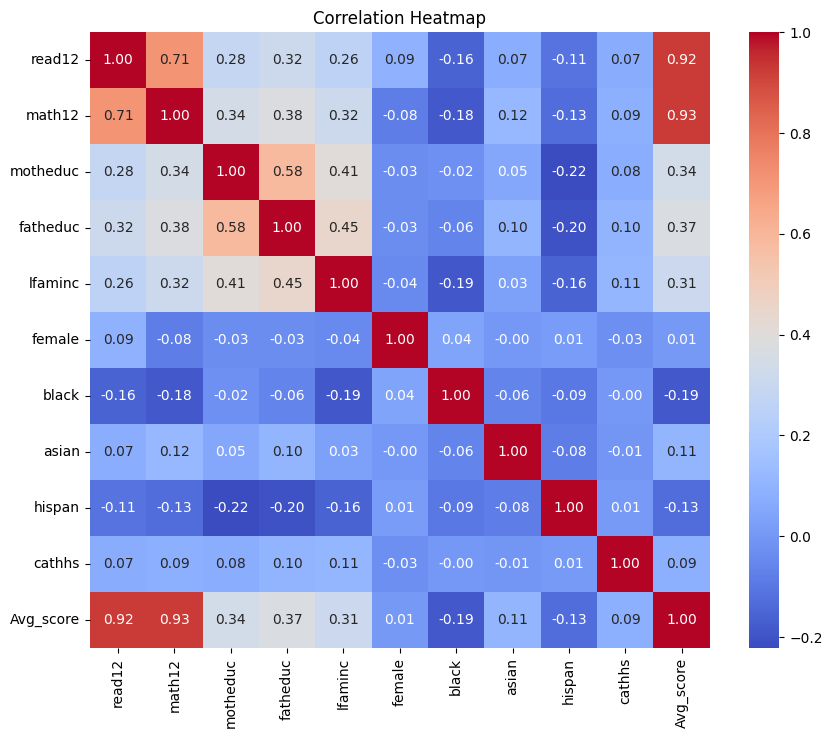

In [5]:
#Correlation Matrix for exploratory analysis
cols = [
    'read12',
    'math12',
    'motheduc',
    'fatheduc',
    'lfaminc',
    'female',
    'black',
    'asian',
    'hispan',
    'cathhs',
    "Avg_score"
]

corr_matrix = df[cols].corr()



plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()


##### The correlation analysis revealed a strong positive relationship (r=0.71) between mathematics and reading standardized scores. This suggests that both variables capture related dimensions of academic performance, supporting the construction of a combined average-score target variable for classification analysis.

A threshold of 60 was selected to represent a conventional passing academic standard and to convert continuous performance measures into a binary classification target suitable for the model.

In [6]:
#Defining pass/fail classification threshold
df["pass"] =(df["Avg_score"] >=60).astype (int)

In [7]:
# selecting a target variable
y = df['pass']

In [8]:
#spliting the dataset for model bulding
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val,X_test,y_val,y_test = train_test_split(X_temp, y_temp, test_size = 0.5 , random_state = 42)

In [9]:
#data transformation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val =scaler.fit_transform(X_val)
X_test = scaler.transform(X_test)
X_train_val = np.concatenate((X_train, X_val))
y_train_val = np.concatenate((y_train, y_val))

In [10]:
#fitting the model
model = LogisticRegression()
model.fit(X_train_val, y_train_val)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
#model prediction
y_predict = model.predict(X_test)

In [12]:
Report_LR = classification_report(y_test,y_predict)

In [13]:
print(Report_LR)

              precision    recall  f1-score   support

           0       0.80      0.96      0.88      1165
           1       0.52      0.14      0.22       321

    accuracy                           0.79      1486
   macro avg       0.66      0.55      0.55      1486
weighted avg       0.74      0.79      0.74      1486



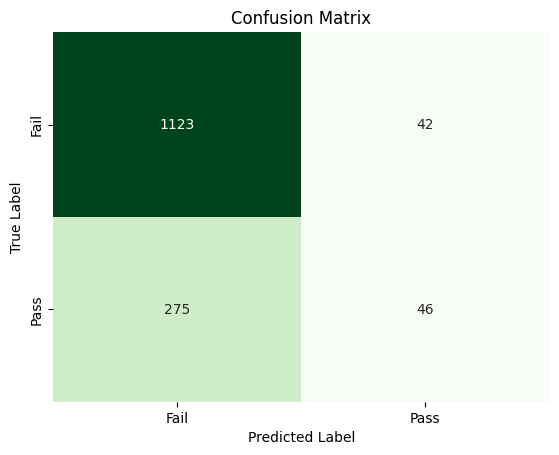

In [14]:

matrix =confusion_matrix( y_test,y_predict)
sns.heatmap(
    matrix,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    xticklabels=['Fail', 'Pass'],
    yticklabels=['Fail', 'Pass']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

#### The model has good accuracy overall of 79% . 
with strong performance on the majority class which is  student failing and weak detection on the minority class which is student passing their exam.
#### Recall = 0.96 in class 0 which is failing exam.
This means model correctly identify 96% of failing students.
#### Precision = 0.80
This means the model predicts failure at 80% accuracy 
#### Recall on 0.14 in class 1 which is passing exam. 
This is a major weakness.  The model only identifies 14% of the actual passing student. Meaning most passing students are incorrectly classified as failing.
#### Precision = 0.52
This means the model predicts passing at 52% accuracy.
Our main concern with our model is Recall and we hope to improve it in the upcoming models.


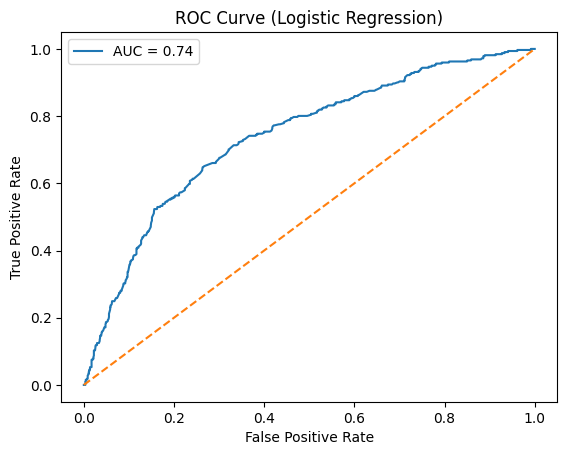

In [15]:

y_predict = model.predict_proba(X_test)[:, 1]


fpr, tpr, _ = roc_curve(y_test, y_predict)
auc_score = roc_auc_score(y_test, y_predict)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()

plt.show()

There is a 74% probability that the model will assign a higher prediction score to a randomly selected passing student than to a randomly selected failing student.

In [16]:
## Tuning the hyperparameters for RandomForestClassifier

best_score = 0
best_params = None
best_model = None

for n in [100, 200, 300]:
    for depth in [3, 5, 8, 10, None]:
        for min_split in [2, 5, 10]:
            
            rf = RandomForestClassifier(
                n_estimators=n,
                max_depth=depth,
                min_samples_split=min_split,
                class_weight='balanced',
                random_state=42
            )
            
            rf.fit(X_train, y_train)
            
            y_val_pred = rf.predict(X_val)
            
            
            score = f1_score(y_val, y_val_pred, average='macro')
            
            if score > best_score:
                best_score = score
                best_params = {
                    'n_estimators': n,
                    'max_depth': depth,
                    'min_samples_split': min_split
                }
                best_model = rf

print("Best validation F1:", best_score)
print("Best parameters:", best_params)

Best validation F1: 0.6628400993916755
Best parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5}


In [17]:
#final model using the hyperparameters 
final_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)


final_rf.fit(X_train_val, y_train_val)

y_pred_rf= final_rf.predict(X_test)


print(classification_report(y_test, y_pred_rf))






              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1165
           1       0.44      0.56      0.49       321

    accuracy                           0.75      1486
   macro avg       0.65      0.68      0.66      1486
weighted avg       0.78      0.75      0.76      1486



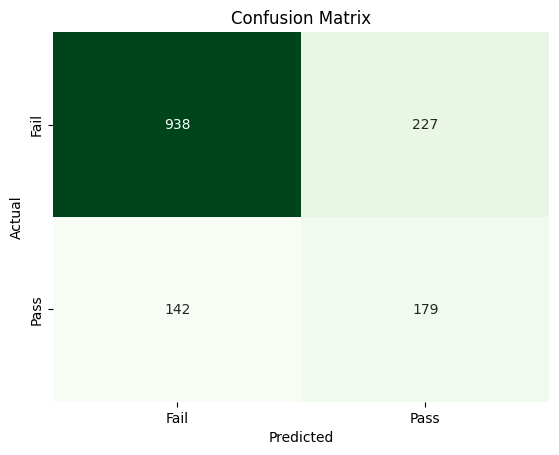

In [18]:
cm =confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Greens',
            cbar =False,
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### Accuracy = 0.75
The model correctly classified 75% of observations overall.


#### Precision = 0.44
The Random forest model performs less effectively in predicting passing students.
 The model predicts pass at 44%. This indicates that 44% of predictions are correct. This shows that the model has relatively high number of false positives

#### Recall = 0.56
The model correctly identifies  56% of actual passing students.
This is a substantial improvement over Logistic Regression, which achieved only 14% recall for the pass class.
#### F1-score = 0.49
The lower F1-score reflects the difficulty of accurately predicting the minority class.

The Random Forest classifier demonstrated substantially improved minority-class (passing the exam) detection compared to the baseline Logistic Regression model. Although the model achieved lower precision for passing students, recall improved considerably, indicating a more balanced ability to classify both pass and fail outcomes.


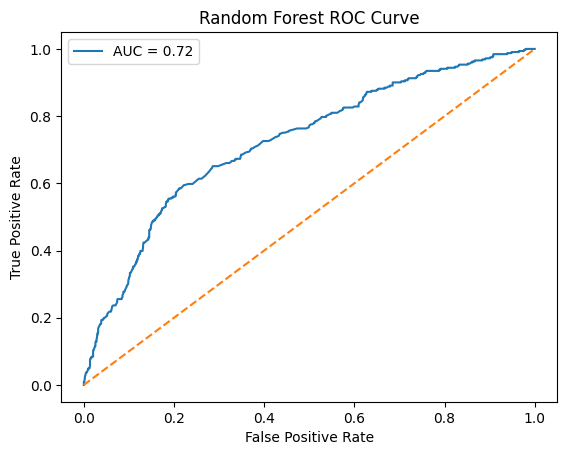

In [19]:

# predict probability and plot roc_curve
y_prob = final_rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

There is a 72% probability that the model will assign a higher prediction score to a randomly selected passing student than to a randomly selected failing student

In [20]:
#	Identifying influential predictors 
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)


importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

fatheduc    0.302613
motheduc    0.283251
lfaminc     0.194321
black       0.051259
female      0.042879
parcath     0.036453
hispan      0.033270
asian       0.028698
cathhs      0.027256
dtype: float64


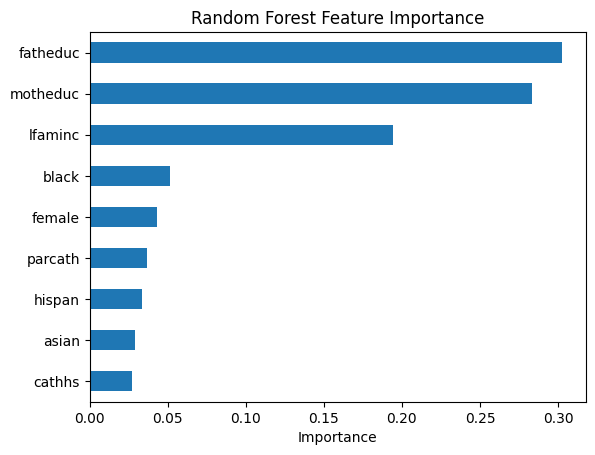

In [21]:
importance.sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

- Father’s years of education was the most influential predictor in the model.
students with more highly educated fathers were more likely to achieve higher academic performance. This may have reflected academic support at home.
- Mother’s education was also highly influential and nearly equal to father’s education.
- This indicates that parental educational background overall plays a substantial role in predicting student success
- Family income was the third most influential predictor - socioeconomic status contributes significantly to student academic performance.
- Inconclusion socioeconomic and family-background characteristics are strongly associated with student academic performance within the dataset


In [22]:
#tunning the hyperparametrs for svm model
best_score = 0
best_params = None
best_model = None

for C in [0.1, 1, 10]:
    
    for gamma in ['scale', 0.1, 0.01]:
        
        svm_model = make_pipeline(
            StandardScaler(),
            SVC(
                kernel='rbf',
                C=C,
                gamma=gamma,
                class_weight='balanced',
                probability=True,
                random_state=42
            )
        )
        
        
        svm_model.fit(X_train, y_train)
        
    
        y_val_pred = svm_model.predict(X_val)
        
       
        score = f1_score(
            y_val,
            y_val_pred,
            average='macro'
        )
        

        if score > best_score:
            
            best_score = score
            
            best_params = {
                'C': C,
                'gamma': gamma
            }
            
            best_model = svm_model

print("Best Validation F1:", best_score)
print("Best Parameters:", best_params)

Best Validation F1: 0.6516266936345771
Best Parameters: {'C': 1, 'gamma': 0.1}


In [ ]:


final_svm = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',
        C=1,
        gamma=0.1,
        class_weight='balanced',
        probability=True,
        random_state=42
    )
)

In [24]:
final_svm.fit(X_train_val, y_train_val)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1


In [25]:
y_pred_svm= final_svm.predict(X_test)

print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.87      0.76      0.81      1165
           1       0.41      0.61      0.49       321

    accuracy                           0.72      1486
   macro avg       0.64      0.68      0.65      1486
weighted avg       0.77      0.72      0.74      1486



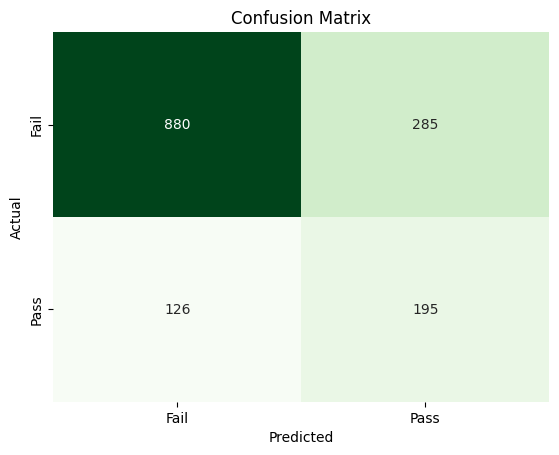

In [26]:
cm =confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
cbar =False,
xticklabels = ['Fail','Pass'],
yticklabels = ['Fail','Pass']
            
           )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

- Accurancy: The model achieved 72% Accurancy
- Precision = 0.87
The model performs strongly in identifying students who were  failing.

When the model predicts that a student will fail 87% of those predictions are correct.

- Recall = 0.76
The model correctly identifies 76% of actual failing students.
This demonstrates that the model is effective at detecting the majority failing students.

- F1-score = 0.81
indicates strong overall classification performance for failing students

- Precision = 0.41
When the model predicts pass, 41% of predictions are correct.
This suggests that the model produces a relatively high number of false-positive pass predictions.
- Recall = 0.61
The model correctly identifies 61% of actual passing students.
This is a substantial improvement compared to the Logistic Regression baseline model, which achieved only 14% recall for the pass exam.
The higher recall indicates the SVM model is better at detecting minority-class observations.

- F1-score = 0.49
The lower F1-score reflects the challenge of balancing precision and recall for the minority pass exam.
Although recall improved significantly, precision remained moderate.


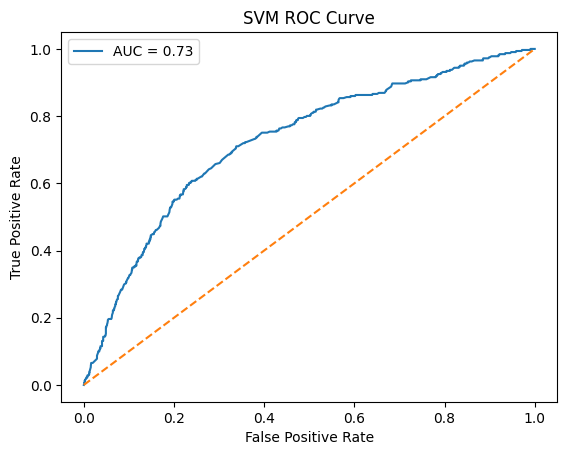

In [27]:

# predict probability and plot roc_curve
y_prob = final_svm.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("SVM ROC Curve")

plt.legend()

plt.show()

There is a 73% probability that the model will assign a higher prediction score to a randomly selected passing student than to a randomly selected failing student

Although Logistic Regression achieved the highest ROC-AUC (0.74) the difference between models is very small. 
These  suggest that:-
- The relationships in the data may be partially linear.
- Nonlinear interactions exist, but are not very dominant 
- class overlap remains significant 


Conclusion
- The machine learning models demonstrated a moderate ability to predict whether a student would pass or fail using demographic and socioeconomic variables. Random Forest and SVM models substantially improved minority-class detection compared to the Logistic Regression baseline, indicating that nonlinear relationships exist within the data. However, classification performance remained imperfect, suggesting that academic success is also influenced by factors not captured in the dataset.
- The models demonstrated that demographic variables, parental education and family income contain meaningful predictive information about academic performance.
